# EDA Automation Using LLM

EDA integration to LLM Summary of the DataSet

Todays Project is About How LLm model helps to summerize

In [1]:
pip install gradio

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install ollama

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Titanic dataset
url=r"C:\Users\umari\OneDrive\Desktop\FSDS DATASETs\titanic_ dataset_final.csv"
df=pd.read_csv(url)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
# Display dataset info
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


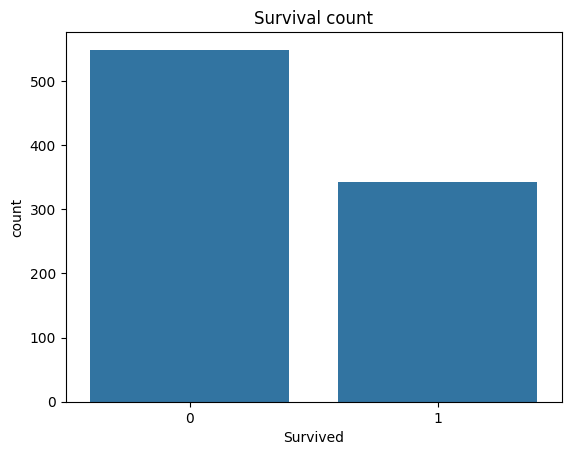

In [5]:
# Survival rate Visualization
sns.countplot(x='Survived',data=df)
plt.title("Survival count")
plt.show()

In [6]:
import ollama

In [7]:
import ollama

def generate_insights(df_summary):
    prompt = f"Analyse the dataset summary and provide insights:\n\n{df_summary}"
    response = ollama.chat(model="mistral",messages=[{"role": "user", "content": prompt}])
    # The actual model reply is inside response["message"]["content"], not ["messages"]
    return response['message']['content']

# Generate AI insights
summary = df.describe().to_string()
insights = generate_insights(summary)
print("\n AI-Generated Insights:\n", insights)


 AI-Generated Insights:
  This dataset appears to be a subset of the Titanic passenger data, which includes information about passengers on the RMS Titanic. Here's an analysis of the dataset summary:

1. **PassengerId**: The dataset contains 891 unique passenger IDs. Since it's a subset, some IDs might be missing.

2. **Survived**: Out of 891 passengers, only 383 (0.3838) survived the sinking of the Titanic. This suggests a high fatality rate due to the infamous disaster.

3. **Pclass**: The Pclass column indicates the passenger's ticket class: 1st (highest), 2nd, or 3rd (lowest). The mean value is 2.3086, which suggests a mix of passengers across all classes.

4. **Age**: The average age of the passengers is 29.699 years old with a standard deviation of 14.526. This indicates a broad age distribution among the passengers.

5. **SibSp**: SibSp represents the number of siblings or spouses aboard the Titanic. The mean value is 0.523, suggesting that many passengers traveled alone or wit

In [8]:
import gradio as gr

def eda_analysis(file):
    df=pd.read_csv(file)
    summary = df.describe().to_string()
    insights = generate_insights(summary)
    return insights

#Create Web InterFace
demo=gr.Interface(fn=eda_analysis,inputs="file",outputs="text",title="AI-Powered EDA with mistral")

#Launch App
demo.launch(share=True)

c:\Users\umari\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


Using existing dataset file at: .gradio\flagged\dataset1.csv
